# `03_correlacoes.ipynb` — Preservação da estrutura de correlação

**Etapa 5 — Avaliação · notebook 3 de 4**

## Objetivo

Verificar se a GAIN preserva a **estrutura de correlação entre variáveis** no test set.
Erro pontual baixo (nb01) e distribuições fiéis (nb02) não garantem que as **relações entre
variáveis** sobrevivam à imputação.

> **Pergunta:** o dataset imputado pela GAIN mantém as relações entre variáveis
> (ex.: OD ↔ pH, Condutividade ↔ Turbidez) que o dataset real exibe?

## Por que correlações importam

O produto final do imputador é um **dataset completo** que alimenta análises ambientais
downstream: regressões, índices compostos de qualidade da água (IQA), detecção de
eventos. Todas essas dependem da **covariância entre variáveis**. Uma imputação que
acerta a média de cada coluna mas **destrói as correlações** (ex.: imputa cada variável
de forma independente) produz um dataset que parece bom marginalmente mas leva a
conclusões enganosas em qualquer análise multivariada. Este é o critério mais ignorado —
e o que mais separa uma boa imputação de uma medíocre.

## Protocolo

- Correlação **de Spearman** (robusta a outliers e monotonicamente invariante — o `ρ` é o
  mesmo na escala física ou normalizada; casa com as caudas pesadas do dataset).
- Calculada sobre **todas as 90 coletas do test** (não só as células mascaradas) — é a
  **estrutura global** que interessa, diferente do erro pontual dos nb01/02.
- **Real:** Spearman sobre os valores observados do test (deleção pairwise dos `NaN`).
- **Imputado (cada método):** matriz completa imputada por seed (as predições persistidas
  já preenchem todas as células), `ρ` calculado por seed e **médio sobre as 3 seeds**
  `[42, 7, 2026]` — mesmo tratamento para GAIN e baselines.
- **Coliformes Termotolerantes fica de fora** (0 observações no test → correlação real
  indefinida): matriz **10×10**, não 13×13 do plano (base reduzida em 2026-06-29 + gap).

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
while not (ROOT / "Data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
CODE = ROOT / "Code"

SPLIT_DIR = ROOT / "Data/GoldData/Splited"
MASK_DIR  = ROOT / "Data/GoldData/Masked"
BASE_DIR  = ROOT / "Data/BaselineResults"
EVAL_DIR  = ROOT / "Data/EvalResults"
EDA_CORR  = ROOT / "Data/Figures/01_EDA/tabelas/corr_top_pares.csv"

OUT_TAB = CODE / "6 - Evaluation/tabelas"
OUT_FIG = ROOT / "Data/Figures/05_Evaluation"
for d in (OUT_TAB, OUT_FIG):
    d.mkdir(parents=True, exist_ok=True)

SEEDS = [42, 7, 2026]
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.width", 180)
print("setup ok | correlação de Spearman, escala-invariante")

setup ok | correlação de Spearman, escala-invariante


## 3. Calcular as matrizes de correlação

Uma matriz por método (média das 3 seeds) mais a matriz real. `abreviar` encurta os nomes
só para exibição nos heatmaps.

In [2]:
df_test        = pd.read_parquet(SPLIT_DIR / "test.parquet")
mask_real_test = pd.read_parquet(MASK_DIR / "mask_real_test.parquet")

# Coliformes fora (sem obs. real no test)
VARS = [v for v in mask_real_test.columns if v != "Coliformes Termotolerantes"]
BASELINES = ["knn", "mice", "missforest", "media_estacao",
             "media_global", "mediana_global", "ffill_estacao"]
METODOS = ["gain"] + BASELINES

preds = {"gain": pd.read_parquet(EVAL_DIR / "predictions_gain.parquet")}
for nome in BASELINES:
    preds[nome] = pd.read_parquet(BASE_DIR / f"predictions_{nome}.parquet")

def corr_real():
    # Spearman sobre observados do test (NaN = não observado -> pairwise)
    return df_test[VARS].corr(method="spearman")

def corr_metodo(nome):
    # média das matrizes de Spearman por seed (matriz completa imputada)
    mats = []
    for seed in SEEDS:
        bloco = preds[nome][preds[nome]["seed"] == seed]
        mats.append(bloco[VARS].corr(method="spearman").to_numpy())
    m = np.mean(mats, axis=0)
    return pd.DataFrame(m, index=VARS, columns=VARS)

C_real = corr_real()
C = {m: corr_metodo(m) for m in METODOS}

ABREV = {"DBO":"DBO","OD":"OD","Nitrato":"NO3","Nitrogênio Amoniacal Total":"NH3",
         "Fósforo Total":"P-Tot","Condutividade":"Cond","pH":"pH","Turbidez":"Turb",
         "Temperatura da Água":"Temp","Sólidos Suspensos Totais":"SST"}
abreviar = lambda M: M.rename(index=ABREV, columns=ABREV)
print(f"matrizes {C_real.shape} para real + {len(METODOS)} métodos")
print("\nMatriz de correlação REAL (test, Spearman):")
abreviar(C_real).round(2)

matrizes (10, 10) para real + 8 métodos

Matriz de correlação REAL (test, Spearman):


,DBO,OD,NO3,NH3,P-Tot,Cond,pH,Turb,Temp,SST
DBO,1.00,0.07,0.10,0.22,0.55,-0.67,0.33,0.69,0.41,-0.14
OD,0.07,1.00,-0.12,-0.46,-0.02,0.03,0.57,0.06,0.26,0.72
NO3,0.10,-0.12,1.00,0.07,-0.13,-0.10,-0.04,-0.11,-0.15,0.34
NH3,0.22,-0.46,0.07,1.00,0.13,-0.34,-0.35,0.20,-0.16,-0.70
P-Tot,0.55,-0.02,-0.13,0.13,1.00,-0.60,0.04,0.60,-0.03,0.76
Cond,-0.67,0.03,-0.10,-0.34,-0.60,1.00,-0.39,-0.87,-0.34,-0.09
pH,0.33,0.57,-0.04,-0.35,0.04,-0.39,1.00,0.33,0.57,0.55
Turb,0.69,0.06,-0.11,0.20,0.60,-0.87,0.33,1.00,0.38,-0.39
Temp,0.41,0.26,-0.15,-0.16,-0.03,-0.34,0.57,0.38,1.00,0.77
SST,-0.14,0.72,0.34,-0.70,0.76,-0.09,0.55,-0.39,0.77,1.00


## 4. Norma de Frobenius da diferença

`||C_real − C_método||_F` (raiz da soma dos quadrados das diferenças, usando o triângulo
superior — cada par uma vez). Quanto **menor, melhor**: mede o quanto a estrutura de
correlação imputada se afasta da real. `max_abs_diff` = maior degradação num único par.

In [3]:
iu = np.triu_indices(len(VARS), k=1)  # triângulo superior, sem diagonal
r_up = C_real.to_numpy()[iu]

linhas = []
for m in METODOS:
    d = C[m].to_numpy()[iu] - r_up
    d_valid = d[~np.isnan(d)]
    linhas.append({
        "metodo": m,
        "frobenius_diff": float(np.sqrt(np.sum(d_valid ** 2))),
        "max_abs_diff": float(np.max(np.abs(d_valid))),
        "n_pares": int(len(d_valid)),
    })
corr_diff = pd.DataFrame(linhas).sort_values("frobenius_diff").reset_index(drop=True)
print("Ranking por norma de Frobenius (menor = estrutura melhor preservada):")
corr_diff.round(4)

Ranking por norma de Frobenius (menor = estrutura melhor preservada):


,metodo,frobenius_diff,max_abs_diff,n_pares
0,mediana_global,1.6101,0.8512,45
1,media_global,1.6594,0.8990,45
2,gain,1.6860,0.9366,45
3,knn,1.6949,1.1487,45
4,mice,1.6980,0.9585,45
5,ffill_estacao,1.8218,0.9687,45
6,media_estacao,2.0146,1.2386,45
7,missforest,2.0826,1.0697,45


## 5. Heatmaps: real vs GAIN vs melhor baseline vs diferença

Grid 2×2: matriz real, GAIN, o **melhor baseline** (menor Frobenius) e a **diferença
`GAIN − real`** (vermelho = GAIN superestima a correlação, azul = subestima). Pares com
maior degradação saltam na 4ª célula.

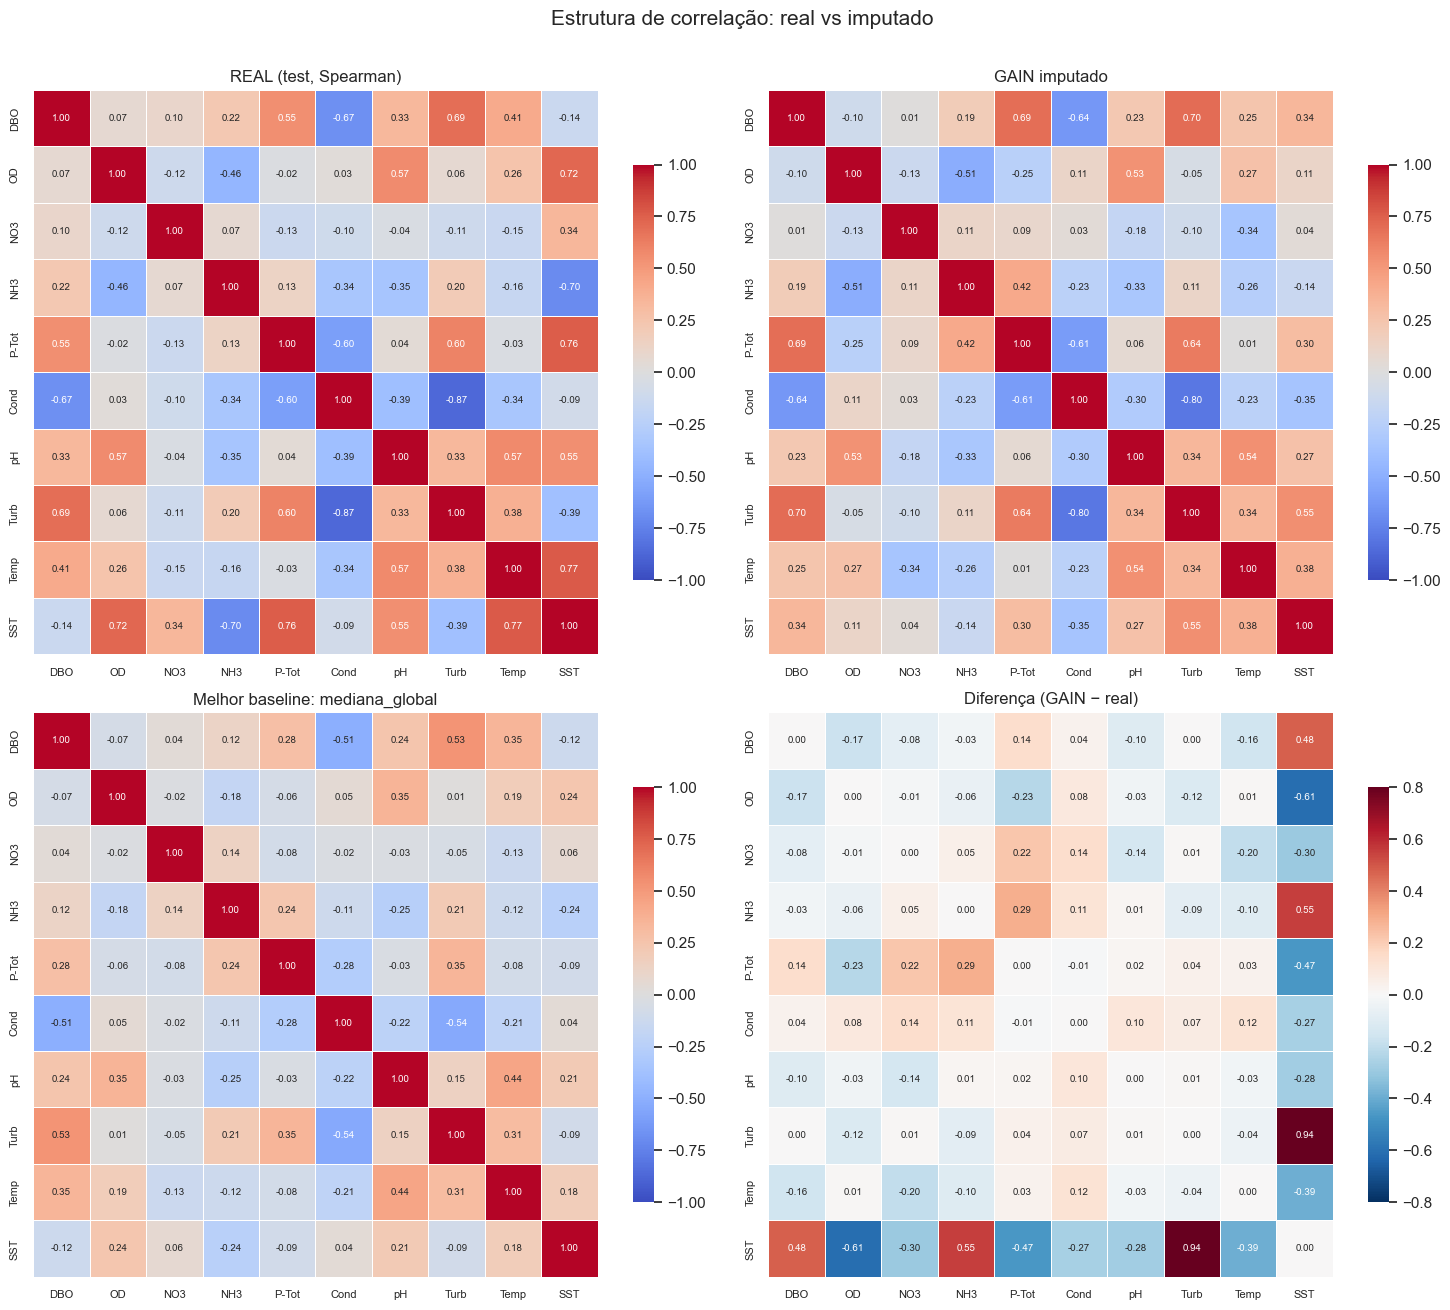

melhor baseline (Frobenius): mediana_global
figura salva: corr_real_vs_imputado.png


In [4]:
melhor_base = corr_diff[corr_diff.metodo != "gain"].iloc[0]["metodo"]
diff_gain = C["gain"] - C_real

fig, axes = plt.subplots(2, 2, figsize=(15, 13))
def hm(ax, M, titulo, diff=False):
    sns.heatmap(abreviar(M), ax=ax, vmin=-1 if not diff else -0.8,
                vmax=1 if not diff else 0.8, cmap="coolwarm" if not diff else "RdBu_r",
                center=0, annot=True, fmt=".2f", annot_kws={"size":7},
                square=True, cbar_kws={"shrink":.7}, linewidths=.5)
    ax.set_title(titulo, fontsize=12)
    ax.tick_params(labelsize=8)
hm(axes[0,0], C_real, "REAL (test, Spearman)")
hm(axes[0,1], C["gain"], "GAIN imputado")
hm(axes[1,0], C[melhor_base], f"Melhor baseline: {melhor_base}")
hm(axes[1,1], diff_gain, "Diferença (GAIN − real)", diff=True)
fig.suptitle("Estrutura de correlação: real vs imputado", fontsize=15, y=1.005)
fig.tight_layout()
fig.savefig(OUT_FIG / "corr_real_vs_imputado.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"melhor baseline (Frobenius): {melhor_base}")
print(f"figura salva: {(OUT_FIG / 'corr_real_vs_imputado.png').name}")

## 6. Scatter `ρ_real × ρ_imputado`

Cada ponto é **um par de variáveis** (45 pares do triângulo superior); a posição compara a
correlação real (x) com a imputada (y). **Pontos sobre a diagonal `y = x` = correlação
preservada.** GAIN em destaque; os métodos que imputam cada variável isoladamente tendem a
puxar os pontos para `y ≈ 0` (achatamento da estrutura).

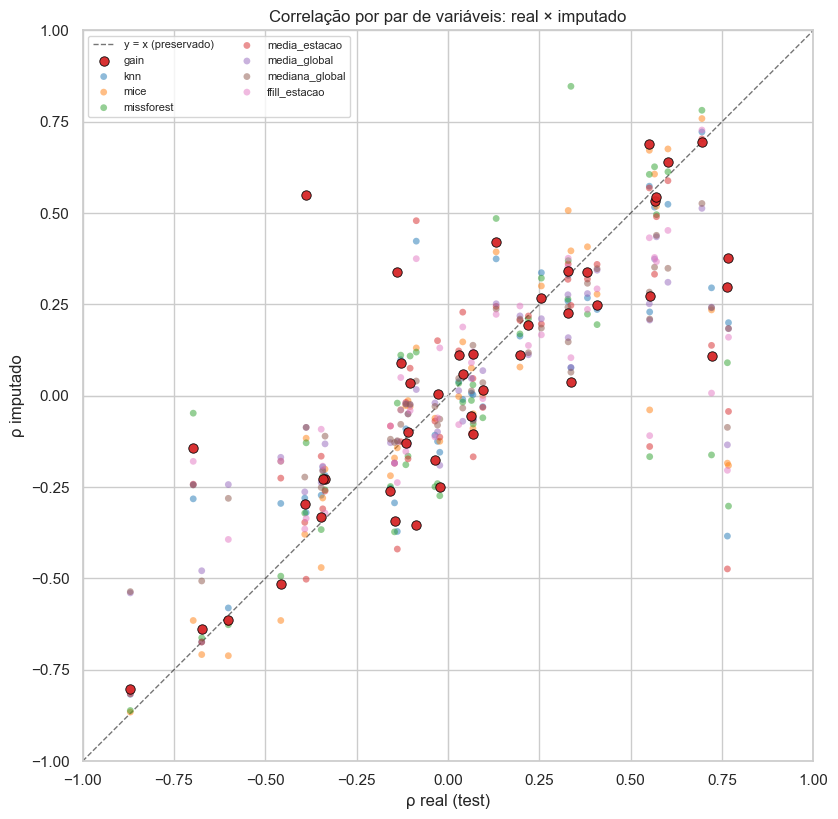

figura salva: corr_scatter_rho.png


In [5]:
paleta = {m: c for m, c in zip(BASELINES, sns.color_palette("tab10", len(BASELINES)))}
paleta["gain"] = "#d62728"
fig, ax = plt.subplots(figsize=(8.5, 8.5))
ax.plot([-1, 1], [-1, 1], "k--", lw=1, alpha=.6, label="y = x (preservado)")
ax.axhline(0, color="0.8", lw=.8); ax.axvline(0, color="0.8", lw=.8)
for m in METODOS:
    y = C[m].to_numpy()[iu]
    ax.scatter(r_up, y, s=(46 if m == "gain" else 24),
               color=paleta[m], alpha=(.95 if m == "gain" else .5),
               edgecolor="black" if m == "gain" else "none",
               linewidth=.6, label=m, zorder=5 if m == "gain" else 3)
ax.set_xlabel("ρ real (test)"); ax.set_ylabel("ρ imputado")
ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_aspect("equal")
ax.set_title("Correlação por par de variáveis: real × imputado")
ax.legend(fontsize=8, loc="upper left", ncol=2)
fig.tight_layout()
fig.savefig(OUT_FIG / "corr_scatter_rho.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"figura salva: {(OUT_FIG / 'corr_scatter_rho.png').name}")

## 7. Preservação de pares significativos

Da EDA (`01_EDA/tabelas/corr_top_pares.csv`): pares com `|ρ| > 0.5` e `p < 0.05` no dataset
completo. Para cada método, contamos em quantos desses a correlação imputada **mantém o
sinal e `|ρ| > 0.4`** (limiar mais frouxo — pedimos que a relação sobreviva, não que seja
idêntica). Vira a coluna `n_pares_significativos_preservados` em `corr_diff.csv`.

In [6]:
eda = pd.read_csv(EDA_CORR, encoding="utf-8")
pares_sig = [(r["var1"], r["var2"], r["rho"]) for _, r in eda.iterrows()
             if abs(r["rho"]) > 0.5 and r["pvalue"] < 0.05
             and r["var1"] in VARS and r["var2"] in VARS]
print(f"pares significativos de referência (EDA): {len(pares_sig)}")
for v1, v2, rho in pares_sig:
    print(f"   {ABREV[v1]:5s}↔{ABREV[v2]:5s}  ρ_EDA={rho:+.2f} | ρ_real_test={C_real.loc[v1,v2]:+.2f}")

def preservados(nome):
    cnt = 0
    for v1, v2, rho_eda in pares_sig:
        rho_m = C[nome].loc[v1, v2]
        if not np.isnan(rho_m) and abs(rho_m) > 0.4 and np.sign(rho_m) == np.sign(rho_eda):
            cnt += 1
    return cnt

corr_diff["n_pares_significativos_preservados"] = corr_diff["metodo"].map(preservados)
corr_diff["de_pares_sig"] = len(pares_sig)
corr_diff.to_csv(OUT_TAB / "corr_diff.csv", index=False, encoding="utf-8")
print(f"\nsalvo: {(OUT_TAB / 'corr_diff.csv').name}")
corr_diff.round(4)

pares significativos de referência (EDA): 5
   Cond ↔Turb   ρ_EDA=-0.59 | ρ_real_test=-0.87
   DBO  ↔Turb   ρ_EDA=+0.57 | ρ_real_test=+0.69
   OD   ↔pH     ρ_EDA=+0.55 | ρ_real_test=+0.57
   DBO  ↔Cond   ρ_EDA=-0.51 | ρ_real_test=-0.67
   DBO  ↔P-Tot  ρ_EDA=+0.51 | ρ_real_test=+0.55

salvo: corr_diff.csv


,metodo,frobenius_diff,max_abs_diff,n_pares,n_pares_significativos_preservados,de_pares_sig
0,mediana_global,1.6101,0.8512,45,3,5
1,media_global,1.6594,0.8990,45,3,5
2,gain,1.6860,0.9366,45,5,5
3,knn,1.6949,1.1487,45,5,5
4,mice,1.6980,0.9585,45,5,5
5,ffill_estacao,1.8218,0.9687,45,4,5
6,media_estacao,2.0146,1.2386,45,4,5
7,missforest,2.0826,1.0697,45,5,5


## 8. Síntese — preservação da estrutura de correlação

In [7]:
g = corr_diff[corr_diff.metodo == "gain"].iloc[0]
pos_gain = int(corr_diff.reset_index(drop=True).index[corr_diff.metodo.values == "gain"][0]) + 1
melhor = corr_diff.iloc[0]

# pares-chave OD↔pH e nutrientes
def rho_par(v1, v2, nome): return C[nome].loc[v1, v2]
print("SÍNTESE — CORRELAÇÕES (test set, Spearman)")
print("=" * 62)
print(f"Ranking Frobenius (1=melhor): GAIN em {pos_gain}º de {len(corr_diff)}")
print(f"   melhor: {melhor['metodo']} (F={melhor['frobenius_diff']:.3f}) | "
      f"GAIN F={g['frobenius_diff']:.3f}")
print(f"GAIN preserva {int(g['n_pares_significativos_preservados'])}/{int(g['de_pares_sig'])} "
      f"pares significativos (|ρ|>0.4, mesmo sinal)")
print(f"Maior degradação num par (GAIN): {g['max_abs_diff']:.3f}")
print("\nPares-chave (ρ): real vs GAIN vs melhor baseline")
for v1, v2 in [("OD","pH"), ("Condutividade","Turbidez"), ("DBO","Fósforo Total")]:
    print(f"   {ABREV[v1]:5s}↔{ABREV[v2]:5s}  real={C_real.loc[v1,v2]:+.2f} | "
          f"GAIN={rho_par(v1,v2,'gain'):+.2f} | {melhor['metodo']}={rho_par(v1,v2,melhor['metodo']):+.2f}")

SÍNTESE — CORRELAÇÕES (test set, Spearman)
Ranking Frobenius (1=melhor): GAIN em 3º de 8
   melhor: mediana_global (F=1.610) | GAIN F=1.686
GAIN preserva 5/5 pares significativos (|ρ|>0.4, mesmo sinal)
Maior degradação num par (GAIN): 0.937

Pares-chave (ρ): real vs GAIN vs melhor baseline
   OD   ↔pH     real=+0.57 | GAIN=+0.53 | mediana_global=+0.35
   Cond ↔Turb   real=-0.87 | GAIN=-0.80 | mediana_global=-0.54
   DBO  ↔P-Tot  real=+0.55 | GAIN=+0.69 | mediana_global=+0.28


### Leitura

A norma de Frobenius resume, num número, o quanto cada método distorce a teia de
correlações; o scatter mostra **como** distorce (achatamento em direção a `y=0` vs ruído em
torno da diagonal); a contagem de pares significativos traduz isso para o que importa na
prática — as relações ecológicas conhecidas (OD↔pH, nutrientes, condutividade↔turbidez)
sobrevivem?

**Cuidado de interpretação:** no test são só 90 coletas, e a correlação real de alguns
pares (ex.: envolvendo SST, com 16 observações) tem `n` pairwise baixo e é ruidosa — a
"referência" não é perfeita. Por isso ancoramos os pares significativos na EDA (n~600),
não na correlação do test isoladamente.

Cruzando com os nb01/02: se a GAIN preservar a estrutura tão bem quanto o KNN aqui, o
argumento do relatório final deixa de ser "quem tem menor RMSE" e passa a ser "a GAIN
entrega um dataset multivariadamente coerente" — o critério que o PIBIC anterior não mediu.

**Próximo notebook:** `04_robustez.ipynb` (sensibilidade à taxa de mascaramento
`{10, 20, 30, 50}%`).